# Create Figure 1 and perform associated statistical analyses

* Figure 1a: The Yeast Interactome PPI network (NetworkX) with annotations labelled
* Figure 1b: Association of essentiality with hubs
* Figure 1c: Number of phosphorylation sites in hubs/non-hubs
* Figure 1d: Stability by melting temperatures of hubs/non-hubs
* Figure 1e: Melting point for phospho/non-phospho proteins
* Figure 1f: Melting point for four categories: hub/phospho, hub/nonphospho, nonhub/phospho, nonhub/nonphospho 

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm, trange
import numpy as np
import networkx as nx
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact

In [2]:
# load the edge information as a pd.DataFrame object
EDGES = "../../0-download-inputs/data-files/The_Yeast_Interactome_edges.csv"
edges = pd.read_csv(EDGES)

# load the node information as a pd.DataFrame object
NODES = "../../flatten/processed-data/20251209-s288c-annotated-PPI-net.pkl"
nodes = pd.read_pickle(NODES)

# create the NetworkX graph object
graph = nx.from_pandas_edgelist(edges, "source", "target", create_using=nx.Graph())

# color for nodes in rendered images
node_color = "magenta"

In [3]:
# function definitions
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid huge memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

# function to generate a nice, reproducible network visualization
def plot_high_quality_network(
    G,
    title,
    color,
    save_name,
    legend_label,
    node_size=12,
    component_compression=0.4,
    border_frac=0.05,
    k=0.2
):
    fig, ax = plt.subplots(figsize=(3, 3))

    # color variants
    base_color = mcolors.to_rgb(color)
    dark_color = tuple(np.clip(np.array(base_color) * 0.7, 0, 1))
    bright_color = tuple(np.clip(np.array(base_color) * 1.2, 0, 1))

    # --- 1. Base layout ---
    pos = nx.spring_layout(G, seed=42, k=k, iterations=100)

    # --- 2. Component compression (unchanged) ---
    G_und = G if not G.is_directed() else G.to_undirected()
    components = list(nx.connected_components(G_und))

    node_to_comp = {}
    for cid, comp in enumerate(components):
        for n in comp:
            node_to_comp[n] = cid

    comp_centroids = {}
    for cid, comp in enumerate(components):
        xs = [pos[n][0] for n in comp]
        ys = [pos[n][1] for n in comp]
        comp_centroids[cid] = np.array([np.mean(xs), np.mean(ys)])

    all_centroids = np.vstack(list(comp_centroids.values()))
    global_centroid = all_centroids.mean(axis=0)

    f = component_compression

    new_pos = {}
    for cid, comp in enumerate(components):
        old_centroid = comp_centroids[cid]
        new_centroid = global_centroid + f * (old_centroid - global_centroid)
        shift = new_centroid - old_centroid
        for n in comp:
            new_pos[n] = pos[n] + shift

    pos = new_pos

    # --- 3. Normalize AND add border padding in data space ---
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()
    span_x = max_x - min_x if max_x > min_x else 1.0
    span_y = max_y - min_y if max_y > min_y else 1.0

    # map into [border_frac, 1 - border_frac] instead of [0, 1]
    inner_scale_x = 1 - 2 * border_frac
    inner_scale_y = 1 - 2 * border_frac

    for n in pos:
        x, y = pos[n]
        x_norm = (x - min_x) / span_x
        y_norm = (y - min_y) / span_y
        pos[n] = (
            border_frac + inner_scale_x * x_norm,
            border_frac + inner_scale_y * y_norm,
        )

    # --- 4. Draw edges ---
    edges = np.array(list(G.edges()))
    np.random.shuffle(edges)
    n_edges = len(edges)
    alphas = np.linspace(0.05, 0.25, n_edges)
    widths = np.linspace(0.1, 0.8, n_edges)

    for i, (u, v) in enumerate(edges):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot(
            [x0, x1],
            [y0, y1],
            color=color,
            lw=widths[i],
            alpha=alphas[i],
            solid_capstyle="round",
            zorder=i,
        )

    # --- 5. Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_size,
        node_color=bright_color,
        alpha=0.9,
        linewidths=0.4,
        edgecolors='black'
    )


    # --- 6. Axes settings: include the padding region ---
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    if title:
        ax.set_title(title)

    fig.text(
        0.5,
        -0.02,
        f"{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges",
        ha="center",
        fontsize=10,
    )

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches="tight", facecolor="white", dpi=300)
    plt.show()

# convert raw output from bootstrapping into a lower and upper CI
def percentile_ci(x, alpha=0.05):
    """Return (lower, upper) percentile CI."""
    lower, upper = np.percentile(x, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lower, upper

# pre-process ptm_gold phosphorylation site information
def process_ptm_gold_column(df):
    def count_and_check_uniqueness(value):
        if pd.isna(value):
            return np.nan
        parts = value.split(";")
        if len(parts) != len(set(parts)):
            print(f"Warning: duplicate entries found in '{value}'")
        return len(parts)

    df["n_ptm_gold"] = df["ptm_gold"].apply(count_and_check_uniqueness)
    return df

### Figure 1a, PPI network
* render the Matthias Mann Lab's Yeast Interactome network in NetworkX

/home/dan182/miniconda3/envs/anyi/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


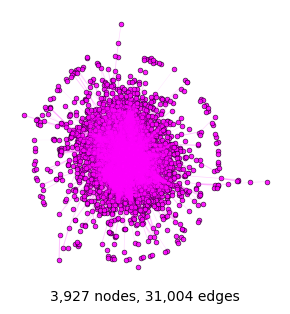

In [4]:
# plot MS network
plot_high_quality_network(
    graph,
    title=f"",
    color=node_color,
    save_name="1a-v1.svg",
    legend_label="",
    component_compression=0.5,
    k=0.2
)

### Figure 1b, association of essential proteins with hubs

* first, look at the actual sample and build the contigency table, compute odds ratio, and get the p-value
* to enable this, need to compute which proteins are hubs based on some definition

In [5]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)
nodes["hub"] = nodes["degree_centrality"] >= threshold

<Figure size 640x480 with 0 Axes>

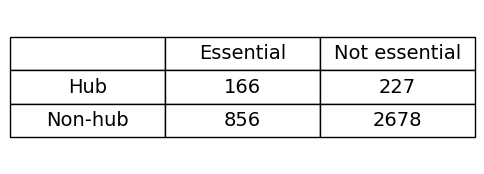

The odds ratio is: 2.29
The p-value is   : 1.78e-13


In [6]:
# compute the values of {a, b, c, d} and construct the contingency table
a = len(nodes[(nodes["hub"] == True ) & (nodes["essential"] == True )])
b = len(nodes[(nodes["hub"] == True ) & (nodes["essential"] == False)])
c = len(nodes[(nodes["hub"] == False) & (nodes["essential"] == True )])
d = len(nodes[(nodes["hub"] == False) & (nodes["essential"] == False)])

# put values into a new format to enable a nice print statement & analysis
contingency_table = pd.DataFrame({"Essential"    : [a, c], 
                                  "Not essential": [b, d]},
                                  index = ["Hub", "Non-hub"])

# create a table from our contingency_table using matplotlib
plt.clf()
fig, ax    = plt.subplots(figsize = (3, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

# use the fisher_exact function from scipy.stats to compute the odds ratio and p-value
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.2e" %fisher_p_value)

* now that we have the sample contingency table and odds ratio, let's bootstrap to determine the 95% confidence interval

In [8]:
# number of bootstrap samples to generate
B = 1_000_000

# number of samples to draw with replacement
n = 3927

# alpha value for the confidence interval
alpha = 0.05

# np.array objects to hold bootstrap samples
boot_a  = np.empty(B, dtype=int)
boot_b  = np.empty(B, dtype=int)
boot_c  = np.empty(B, dtype=int)
boot_d  = np.empty(B, dtype=int)
boot_or = np.empty(B, dtype=float)

# loop over B samples with a tqdm loading bar
for i in tqdm(range(B), desc=f"Bootstrapping (B={B})", unit="sample"):
    # resample rows with replacement
    sample = nodes.sample(n=n, replace=True)

    # compute a, b, c, d for bootstrap sample
    a_i = len(sample[(sample["hub"] == True ) & (sample["essential"] == True )])
    b_i = len(sample[(sample["hub"] == True ) & (sample["essential"] == False)])
    c_i = len(sample[(sample["hub"] == False) & (sample["essential"] == True )])
    d_i = len(sample[(sample["hub"] == False) & (sample["essential"] == False)])

    # store results in np.array objects
    boot_a[i] = a_i
    boot_b[i] = b_i
    boot_c[i] = c_i
    boot_d[i] = d_i

    # compute contingency table for this bootstrap sample
    table_i = np.array([[a_i, b_i],
                        [c_i, d_i]])

    # compute odds ratio using Fisher's exact test
    or_i, _ = fisher_exact(table_i, alternative="two-sided")

    # store results in np.array object
    boot_or[i] = or_i

# compute 95% CIs 
a_ci  = percentile_ci(boot_a,  alpha=alpha)
b_ci  = percentile_ci(boot_b,  alpha=alpha)
c_ci  = percentile_ci(boot_c,  alpha=alpha)
d_ci  = percentile_ci(boot_d,  alpha=alpha)
or_ci = percentile_ci(boot_or, alpha=alpha)

# print detailed CIs 
print("95% bootstrap CIs (percentile method)")
print(f" a: {a}  [{a_ci[0]:.0f}, {a_ci[1]:.0f}]")
print(f" b: {b}   [ {b_ci[0]:.0f},  {b_ci[1]:.0f}]")
print(f" c: {c}   [ {c_ci[0]:.0f},  {c_ci[1]:.0f}]")
print(f" d: {d}   [ {d_ci[0]:.0f},  {d_ci[1]:.0f}]")
print(f"\n OR: {odds_ratio:.2f} [{or_ci[0]:.2f}, {or_ci[1]:.2f}]")

Bootstrapping (B=1000000): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [1:51:43<00:00, 149.17sample/s]


95% bootstrap CIs (percentile method)
 a: 166  [142, 191]
 b: 227   [ 199,  256]
 c: 856   [ 806,  907]
 d: 2678   [ 2621,  2735]

 OR: 2.29 [1.84, 2.83]


### Figure 1c, relationship between number of phosphorylation sites and hubs

In [49]:
# add the "n_ptm_gold" column for this analysis
nodes = process_ptm_gold_column(nodes)

In [55]:
hub = nodes.loc[nodes["hub"], "n_ptm_gold"].dropna()
nonhub = nodes.loc[~nodes["hub"], "n_ptm_gold"].dropna()

# bootstrap median values for hubs and non-hubs
hub_median, hub_lower, hub_upper = bootstrap_ci_median(hub, B=1_000_000, ci=95, random_state=27)
nonhub_median, nonhub_lower, nonhub_upper = bootstrap_ci_median(nonhub, B=1_000_000, ci=95, random_state=27)

print (f"Median number of phosphorylation sites in hub proteins: {hub_median} [{hub_lower}, {hub_upper}]")
print (f"Median number of phosphorylation sites in non-hub proteins: {nonhub_median} [{nonhub_lower}, {nonhub_upper}]")

Bootstrapping medians: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:41<00:00, 24114.01it/s]

Median number of phosphorylation sites in hub proteins: 4.0 [4.0, 5.0]
Median number of phosphorylation sites in non-hub proteins: 4.0 [4.0, 4.0]


This is our contingency table:



<Figure size 640x480 with 0 Axes>

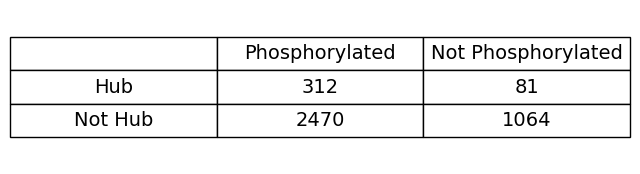

The odds ratio is: 1.66
The p-value is   : 0.0000660


In [58]:
# use a joint criteria to define proteins as phosphorylated or not phosphorylated
has_phospho_flag = (nodes["ptm_gold"].notna())
has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

# create contingency table

# compute the values of {a, b, c, d} and construct the contingency table
a = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == True )])
b = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == False)])
c = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == True )])
d = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == False)])

# put values into a new format to enable a nice print statement & analysis
contingency_table = pd.DataFrame({"Phosphorylated"    : [a, c], 
                                  "Not Phosphorylated": [b, d]},
                                 index = ["Hub", "Not Hub"])

# create a table from our contingency_table using matplotlib
plt.clf()
fig, ax    = plt.subplots(figsize = (4, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

# use the fisher_exact function from scipy.stats to compute the odds ratio and p-value
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.7f" %fisher_p_value)

In [60]:
# number of bootstrap samples to generate
B = 10_000

# number of samples to draw with replacement
n = 3927

# alpha value for the confidence interval
alpha = 0.05

# np.array objects to hold bootstrap samples
boot_a  = np.empty(B, dtype=int)
boot_b  = np.empty(B, dtype=int)
boot_c  = np.empty(B, dtype=int)
boot_d  = np.empty(B, dtype=int)
boot_or = np.empty(B, dtype=float)

# loop over B samples with a tqdm loading bar
for i in tqdm(range(B), desc=f"Bootstrapping (B={B})", unit="sample"):
    # resample rows with replacement
    sample = nodes.sample(n=n, replace=True)

    # compute a, b, c, d for bootstrap sample
    a_i = len(sample[(sample["hub"] == True ) & (sample["phosphorylated"] == True )])
    b_i = len(sample[(sample["hub"] == True ) & (sample["phosphorylated"] == False)])
    c_i = len(sample[(sample["hub"] == False) & (sample["phosphorylated"] == True )])
    d_i = len(sample[(sample["hub"] == False) & (sample["phosphorylated"] == False)])

    # store results in np.array objects
    boot_a[i] = a_i
    boot_b[i] = b_i
    boot_c[i] = c_i
    boot_d[i] = d_i

    # compute contingency table for this bootstrap sample
    table_i = np.array([[a_i, b_i],
                        [c_i, d_i]])

    # compute odds ratio using Fisher's exact test
    or_i, _ = fisher_exact(table_i, alternative="two-sided")

    # store results in np.array object
    boot_or[i] = or_i

# compute 95% CIs 
a_ci  = percentile_ci(boot_a,  alpha=alpha)
b_ci  = percentile_ci(boot_b,  alpha=alpha)
c_ci  = percentile_ci(boot_c,  alpha=alpha)
d_ci  = percentile_ci(boot_d,  alpha=alpha)
or_ci = percentile_ci(boot_or, alpha=alpha)

# print detailed CIs 
print("95% bootstrap CIs (percentile method)")
print(f" a: {a}  [{a_ci[0]:.0f}, {a_ci[1]:.0f}]")
print(f" b: {b}   [ {b_ci[0]:.0f},  {b_ci[1]:.0f}]")
print(f" c: {c}   [ {c_ci[0]:.0f},  {c_ci[1]:.0f}]")
print(f" d: {d}   [ {d_ci[0]:.0f},  {d_ci[1]:.0f}]")
print(f"\n OR: {odds_ratio:.2f} [{or_ci[0]:.2f}, {or_ci[1]:.2f}]")

Bootstrapping (B=10000): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:09<00:00, 142.97sample/s]

95% bootstrap CIs (percentile method)
 a: 166  [279, 345]
 b: 227   [ 64,  99]
 c: 856   [ 2409,  2530]
 d: 2678   [ 1010,  1119]

 OR: 2.29 [1.30, 2.17]


### Figure 1d, stability by melting temperatures of hubs/non-hubs


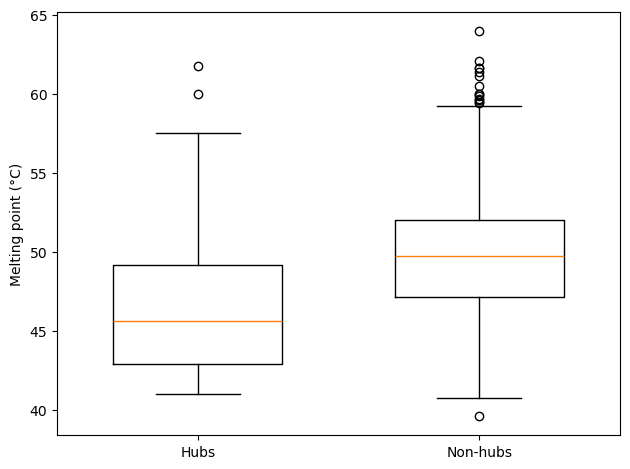

In [61]:
subset = nodes[nodes["meltome-fit-R2"] >= 0.9].copy()

hub_tm = subset.loc[subset["hub"], "meltome-melting-point"].dropna()
nonhub_tm = subset.loc[~subset["hub"], "meltome-melting-point"].dropna()

plt.clf()
plt.boxplot(
    [hub_tm, nonhub_tm],
    positions=[1, 2],     
    widths=0.6,            
)

plt.xticks([1, 2], ["Hubs", "Non-hubs"])
plt.ylabel("Melting point (°C)")   
plt.tight_layout()

/tmp/ipykernel_430872/3197173343.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


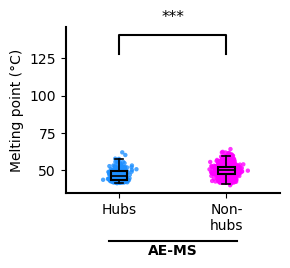

In [67]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [hub_tm, nonhub_tm]
group_colors = ["dodgerblue",    "magenta"]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-\nhubs"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Melting point (°C)")
#ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ms_pair_max  = max(hub_tm.max(), nonhub_tm.max())

ms_y  = ms_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "***")

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"1d-v1.svg")
plt.show()

### Figure 1e

### Figure 1f